# Linear Combination of Hamiltonian Simulation (LCHS)

> The **Linear Combination of Hamiltonian Simulation (LCHS)** method [\[1\]](#ref-lchs) solves linear ODEs of the form $\frac{d}{dt}|u\rangle = -A|u\rangle$ on a quantum computer, where $A$ may be non-anti-Hermitian, leading to non-unitary time evolution. It works by expressing the propagator $e^{-At}$ as a continuous linear combination of *unitary* evolutions, which is then discretized and implemented using standard Hamiltonian simulation primitives.
>
> - **Input:**
>   - A matrix $A = L + iH$ with $L \succeq 0$ (positive semidefinite) and $H = H^\dagger$ (Hermitian).
>   - Block-encoding oracles for $H/\alpha_H$ and $L/\alpha_L$.
>   - The evolution time $t$ and target error $\epsilon$.
>
> - **Output:** A quantum state proportional to $e^{-At}|u_0\rangle$, obtained via post-selection on auxiliary qubits.
>
> **Complexity:** The algorithm requires $\mathcal{O}(\alpha_A\, t \log(1/\epsilon))$ queries to the block-encoding oracle for $A$ [\[5\]](#ref-optimal-lchs), where $\alpha_A \geq \|A\|$ is the block-encoding normalization and $\epsilon$ is the target operator-norm error $\|e^{-At} - \tilde{U}\| \leq \epsilon$. This is optimal in all parameters, improving the $\widetilde{O}(\alpha_A\, t \log^{1+o(1)}(1/\epsilon))$ scaling of prior work [\[1\]](#ref-lchs), [\[2\]](#ref-lchs2).
>
> ---
>
> **Keywords:** Non-unitary dynamics, Linear Differential Equations, Hamiltonian Simulation, Block Encoding, GQSP, Kernel Methods, Open Quantum Systems.


## Background

### The Problem

We wish to solve the linear ODE

$$\frac{d}{dt}|u\rangle = -A\,|u\rangle, \qquad |u(0)\rangle = |u_0\rangle,$$

where $A \in \mathbb{C}^{N \times N}$. When $A$ is not anti-Hermitian, the solution $|u(t)\rangle = e^{-At}|u_0\rangle$ is **non-unitary** and cannot be directly implemented as a quantum gate.

We decompose $A = L + iH$ where:
- $H = \frac{1}{2i}(A - A^\dagger)$ is Hermitian (the conservative/oscillatory part),
- $L = \frac{1}{2}(A + A^\dagger)$ is positive semidefinite (the dissipative/damping part).

**Source terms.** The homogeneous equation above can be extended to the inhomogeneous case $\frac{d}{dt}|u\rangle = -A|u\rangle + |b(t)\rangle$. Via Duhamel's principle, the solution is

$$|u(t)\rangle = e^{-At}|u_0\rangle + \int_0^t e^{-A(t-s)}|b(s)\rangle\,ds.$$

Each term involves evaluating the non-unitary propagator $e^{-A\tau}$ and can therefore be handled by LCHS. In practice, the integral is discretized using a quadrature rule, and each quadrature point contributes an additional LCHS call at the corresponding time $(t - s)$ (see [\[5\]](#ref-optimal-lchs), Sec. 1.1.2 and [\[2\]](#ref-lchs2)).

### The LCHS Identity

The central insight of LCHS is the integral identity (Eq. 4 in [\[5\]](#ref-optimal-lchs), originally [\[1\]](#ref-lchs)):

$$e^{-At} = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} \hat{f}(k)\, e^{-i(kL + H)t}\, dk,$$

where $\hat{f}(k)$ is the Fourier transform of a function $f$ chosen to satisfy $f(x) = e^{-x}$ for $x \geq 0$. For each $k \in \mathbb{R}$, the matrix $H + kL$ is Hermitian, so the exponential $e^{-i(kL+H)t}$ is a unitary operator that can be implemented using standard Hamiltonian simulation techniques.

In practice this integral is truncated to a finite interval $[-R, R]$ (where $R$ is the truncation radius) and discretized into a finite sum that can be implemented via LCU on a quantum computer. A key innovation of [\[5\]](#ref-optimal-lchs) is the *approximate* LCHS: the kernel $f$ need only *approximate* exponential decay (rather than match it exactly), which circumvents a no-go result from prior work and enables the optimal $O(\alpha_A\, t \log(1/\epsilon))$ query complexity.

### Kernel Function

Reference [\[5\]](#ref-optimal-lchs) uses the kernel function (Eq. 9, with $j=2$, $y=1$):

$$\hat{f}_2(k;\gamma,c) = \frac{2}{\sqrt{2\pi}} \frac{e^{c(1-ik)}\, e^{-(k^2+1)/(4\gamma^2)}}{1+k^2}.$$

This is a product of a Lorentzian $1/(1+k^2)$ and a Gaussian $e^{-k^2/(4\gamma^2)}$. The Lorentzian alone is the Fourier transform of exact exponential decay $e^{-|x|}$, but its tails decay only as $1/k^2$, making it expensive to truncate the integral. The Gaussian envelope suppresses the tails exponentially, enabling truncation to a finite interval $[-R, R]$ with small error. The tradeoff is that the kernel now only *approximates* exponential decay, with the approximation quality controlled by $\gamma$: larger $\gamma$ gives a wider (flatter) Gaussian and a better approximation, at the cost of a larger truncation radius $R$.

The shift parameter $c$ controls the normalization factor $\alpha_{\hat{f}_2} \leq e^c$, which determines the post-selection success probability. 

Theorem 2 of [\[5\]](#ref-optimal-lchs) sets $\gamma = \frac{1}{c}\sqrt{c + \log\frac{1+1/(2\pi)}{\epsilon_{\mathrm{lchs}}}}$ and $R = 2c\gamma^2$ to guarantee kernel approximation error $\leq \epsilon_{\mathrm{lchs}}$.

### Discretization

The integral is discretized on a uniform grid of $N = 2^J$ points with spacing $h = 2R/N$ over the interval $[-R, R)$ ([\[5\]](#ref-optimal-lchs), Theorem 3, which proves exponential convergence of the uniform quadrature):

$$e^{-At} \approx \frac{h}{\sqrt{2\pi}} \sum_{j=-N/2}^{N/2-1} \hat{f}_2(k_j)\, e^{-i(k_j L + H)t}, \qquad k_j = h \cdot j.$$

The stepsize $h$ is chosen according to:

$$h \leq \frac{\pi}{\|L\| \cdot t/2 + \log\!\left(\frac{64\, e^{3c/2}}{15\,\epsilon_{\mathrm{disc}}}\right)},$$

The number of grid points $N = 2^J$ is then $J = \lceil \log_2(2R/h) \rceil$. Note that a uniform quadrature is sufficient. This sum is implemented via LCU, with the kernel values $\hat{f}_2(k_j)$ as coefficients.

### Quantum Circuit Structure

The full LCHS quantum circuit consists of the following components:

1. **Kernel state preparation**: Load $|\hat{f}_2(k_j)|$ into an auxiliary register $|j\rangle$.
2. **Block-encoding of $H + k_j L$**: For each grid point $j$, block-encode the Hermitian operator $(H + k_j L)/\alpha$, where $\alpha = \alpha_L R + \alpha_H$ is the normalization.
3. **Hamiltonian simulation**: In this demo we apply the Jacobi-Anger polynomial approximation of $e^{-i(H+k_j L)\alpha t}$ using Generalized QSP on the walk operator derived from the block encoding.
4. **Post-selection**: Measure all auxiliary qubits in the $|0\rangle$ state to extract the desired output.

## Preliminaries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

from classiq import *
from classiq.applications.qsp import (
    gqsp_phases,
    poly_jacobi_anger_degree,
    poly_jacobi_anger_exp_cos,
)
from classiq.qmod.symbolic import pi

### Problem Definition and Parameters

We define the Hamiltonians $H$ and $L$ and derive all algorithm parameters — state size, block-encoding normalization, kernel shape, and error budget — from these operators and the desired precision.

In [2]:
H_PAULI = 0.5 * Pauli.X(0) * Pauli.X(1) + 0.5 * Pauli.Z(0) * Pauli.Z(1)
L_PAULI = 0.5 * Pauli.I(0) * Pauli.I(1) + 0.5 * Pauli.Z(0) * Pauli.I(1)

STATE_SIZE = H_PAULI.num_qubits
n_pauli_terms = max(len(H_PAULI.terms), len(L_PAULI.terms))
BLOCK_SIZE = max(1, int(np.ceil(np.log2(n_pauli_terms))))
alpha_H = sum(abs(t.coefficient) for t in H_PAULI.terms)
alpha_L = sum(abs(t.coefficient) for t in L_PAULI.terms)

T = 1  # evolution time

GQSP_EPS = 1e-5  # GQSP polynomial approximation error
LCHS_EPS = 1e-2  # LCHS kernel approximation error (Theorem 2 of [5])
DISC_EPS = 1e-2  # discretization / quadrature error (Theorem 3 of [5])
EPS = GQSP_EPS + LCHS_EPS + DISC_EPS

c = 2.0  # kernel shift (trades normalization e^c vs. integration range)

gamma = np.sqrt(c + np.log((1 + 1 / (2 * np.pi)) / LCHS_EPS)) / c
R = 2 * c * gamma**2  # truncation radius

h = np.pi / (
    alpha_L * T / 2 + np.log(64 * np.exp(3 * c / 2) / (15 * DISC_EPS))
)  # step size
J_SIZE = int(np.ceil(np.log2(2 * R / h)))
h = R / 2 ** (J_SIZE - 1)  # actual h after rounding to power-of-2 grid

alpha_tot = alpha_L * R + alpha_H

GQSP_SCALE_FACTOR = 0.99

print(f"Derived:  gamma={gamma:.4f}, R={R:.4f}, J_SIZE={J_SIZE}")
print(f"Errors:   GQSP_EPS={GQSP_EPS}, LCHS_EPS={LCHS_EPS}, DISC_EPS={DISC_EPS}")
print(f"          EPS (total) = {EPS}")

Derived:  gamma=1.2993, R=6.7529, J_SIZE=6
Errors:   GQSP_EPS=1e-05, LCHS_EPS=0.01, DISC_EPS=0.01
          EPS (total) = 0.02001


Notice that in practice these bounds are worst-case and not tight, and the actual error is much smaller.

## Classical Reference Simulation

Before building the quantum circuit, we implement the LCHS formula classically to verify correctness.

1. **Exact**: Direct matrix exponentiation $e^{-(L+iH)t}|u_0\rangle$.
2. **LCHS**: The discretized sum $\frac{h}{\sqrt{2\pi}} \sum_j \hat{f}_2(k_j)\, e^{-i(H+k_jL)t}|u_0\rangle$ using exact matrix exponentials.

In [3]:
def signed_j_vals(J: int) -> np.ndarray:
    """Signed grid indices: -2^(J-1), ..., 2^(J-1)-1."""
    return np.arange(-(2 ** (J - 1)), 2 ** (J - 1), dtype=int)


def lchs_grid(R: float, J: int):
    """Compute the LCHS discretization grid."""
    N = 2**J
    h = 2 * R / N
    j = signed_j_vals(J)
    k = h * j
    return h, j, k


def kernel_fhat2(k: np.ndarray, gamma: float, c: float) -> np.ndarray:
    r"""Kernel function $\hat{f}_2(k;\gamma,c)$ from Eq. (6) of [5] with j=2, y=1."""
    k = np.asarray(k, dtype=float)
    return np.exp(-1j * k * c) / (1 + k**2) * np.exp(-(k**2 + 1) / (4 * gamma**2))

In [4]:
def truth_nonunitary(v0, L, H, t):
    """Exact non-unitary evolution: exp(-(L + iH)t) @ v0."""
    return la.expm(-(L + 1j * H) * t) @ v0


def lchs_classical(v0, L, H, t, *, R, J, gamma, c):
    """Discretized LCHS with exact matrix exponentials."""
    v0 = np.asarray(v0, dtype=complex)
    h, j, k = lchs_grid(R, J)
    w = kernel_fhat2(k, gamma=gamma, c=c)

    out = np.zeros_like(v0, dtype=complex)
    for kj, wj in zip(k, w):
        U = la.expm(-1j * (H + kj * L) * t)
        out += wj * (U @ v0)
    return out, h, k, w

### Classical Verification

We verify the LCHS simulation against the exact solution using a random test problem.

In [5]:
def random_hermitian(M: int, *, seed=None, scale=1.0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(M, M)) + 1j * rng.normal(size=(M, M))
    H = (A + A.conj().T) / 2
    return scale * H


def random_psd(M: int, *, seed=None, rank=None, scale=1.0) -> np.ndarray:
    """Random positive semidefinite matrix via B^dag B."""
    rng = np.random.default_rng(seed)
    r = M if rank is None else int(rank)
    B = rng.normal(size=(r, M)) + 1j * rng.normal(size=(r, M))
    return scale * (B.conj().T @ B)


def fidelity(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, dtype=complex), np.asarray(b, dtype=complex)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return 0.0
    a, b = a / np.linalg.norm(a), b / np.linalg.norm(b)
    return float(np.abs(np.vdot(a, b)) ** 2)

In [6]:
CLASSICAL_SIZE = 2**7

H_classical = random_hermitian(CLASSICAL_SIZE)
H_classical /= np.max(np.linalg.svd(H_classical, compute_uv=False))

L_classical = random_psd(CLASSICAL_SIZE)
L_classical /= np.max(np.linalg.svd(L_classical, compute_uv=False))

np.random.seed(1)
v0_classical = np.random.rand(CLASSICAL_SIZE).astype(complex)
v0_classical /= np.linalg.norm(v0_classical)

CLASSICAL_SIZE = 2**7

H_classical = random_hermitian(CLASSICAL_SIZE)
H_classical /= np.max(np.linalg.svd(H_classical, compute_uv=False))

L_classical = random_psd(CLASSICAL_SIZE)
L_classical /= np.max(np.linalg.svd(L_classical, compute_uv=False))

np.random.seed(1)
v0_classical = np.random.rand(CLASSICAL_SIZE).astype(complex)
v0_classical /= np.linalg.norm(v0_classical)

R_classical, J_classical = R, 6
t_classical = 10

out_exact = truth_nonunitary(v0_classical, L_classical, H_classical, t_classical)

out_lchs, *_ = lchs_classical(
    v0_classical,
    L_classical,
    H_classical,
    t_classical,
    R=R_classical,
    J=J_classical,
    gamma=gamma,
    c=c,
)

print(f"Fidelity (LCHS vs exact):  {fidelity(out_exact, out_lchs):.6f}")

Fidelity (LCHS vs exact):  1.000000


## Quantum Implementation

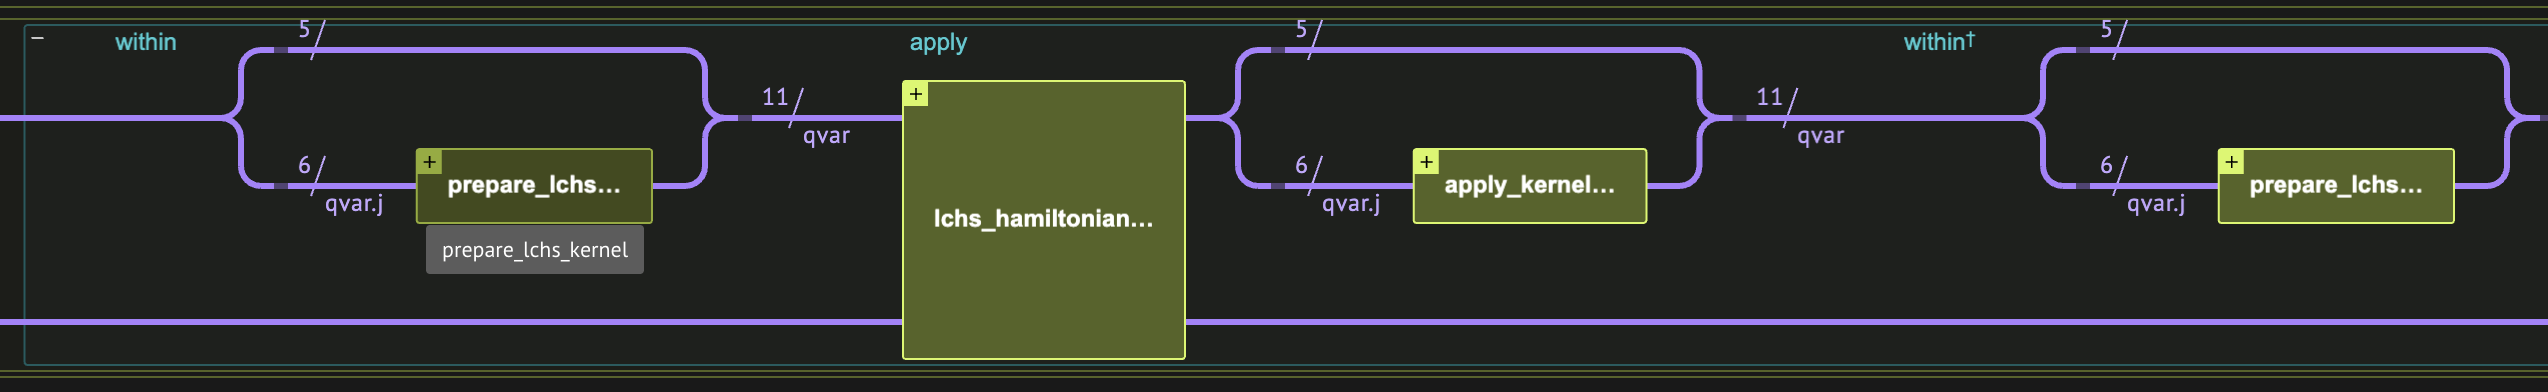

We now implement the full LCHS algorithm as a quantum circuit using Classiq. The circuit follows the structure described in the background:

1. Prepare the kernel amplitudes $|\hat{f}_2(k_j)|$ in the $|j\rangle$ register.
2. Block-encode the $j$-dependent Hamiltonian $(H + k_j L)/\alpha$.
3. Simulate the time evolution via GQSP on the walk operator.
4. Post-select on auxiliary qubits being $|0\rangle$.

### Data Structures

We define quantum struct types for the LCHS circuit. The `LchsBlock` struct holds the auxiliary registers:
- `j`: a signed integer register for the grid index,
- `lcu_block`: auxiliary qubit for the LCU of $H$ and $kL$,
- `linear_block`: auxiliary qubit for the linear block-encoding of $k$ (explained below),
- `matrices_block`: auxiliary qubits for the block-encoding of $H$ and $L$.

In [7]:
class LchsBlock(QStruct):
    lcu_block: QBit
    linear_block: QBit
    matrices_block: QArray[BLOCK_SIZE]


class LchsVar(QStruct):
    x: QNum[STATE_SIZE]
    j: QNum[J_SIZE, SIGNED, 0]
    block: LchsBlock

### Block-Encoding the Hamiltonians

For each grid point $j$, we need a block-encoding of the Hermitian operator

$$\frac{H + k_j L}{\alpha}, \qquad \alpha = \alpha_L R + \alpha_H.$$

This is achieved by an LCU decomposition:

$$\frac{H + k_j L}{\alpha} = \frac{\alpha_L R}{\alpha} \cdot \frac{k_j}{R} \cdot \frac{L}{\alpha_L} + \frac{\alpha_H}{\alpha} \cdot \frac{H}{\alpha_H}.$$

The factor $k_j / R$ is block-encoded using a linear amplitude encoding: $|j\rangle|0\rangle \mapsto \frac{j}{2^{J-1}}|j\rangle|0\rangle + |\perp\rangle$, which embeds the linear function of $j$ into an amplitude. The other constants are applied as part of the LCU probabilities.

The Pauli-decomposed operators $H$ and $L$ (defined in the parameters cell above) are each block-encoded via `lcu_pauli`, which implements the LCU of Pauli terms using ancilla qubits.

In [8]:
@qfunc
def block_encode_H(x: QNum, block: QArray):
    lcu_pauli(H_PAULI * (1 / alpha_H), x, block)


@qfunc
def block_encode_L(x: QNum, block: QArray):
    lcu_pauli(L_PAULI * (1 / alpha_L), x, block)


@qfunc
def linear_be(x: QNum, ind: QBit):
    """
    Linear block-encoding: |j>|0> -> (j/2^(J-1))|j>|0> + |perp>.
    Encodes the linear dependence on the grid index j.
    """
    assign_amplitude_table(
        amplitudes=lookup_table(lambda y: np.abs(y) / 2 ** (x.size - 1), x),
        index=x,
        indicator=ind,
    )
    X(ind)
    control(x < 0, lambda: phase(pi))


@qfunc
def block_encode_hamiltonians(qvar: LchsVar):
    """
    Block-encode sum_j |j><j| (j*L + H) / (R*alpha_L + alpha_H)
    using an LCU of the linear*L and H block-encodings.
    """
    lcu(
        [alpha_L * R, alpha_H],
        unitaries=[
            lambda: (
                linear_be(qvar.j, qvar.block.linear_block),
                block_encode_L(qvar.x, qvar.block.matrices_block),
            ),
            lambda: block_encode_H(qvar.x, qvar.block.matrices_block),
        ],
        block=qvar.block.lcu_block,
    )

### Walk Operator and GQSP Hamiltonian Simulation

Given the block-encoding $U_A$ of $(H + k_j L)/\alpha$, we construct the walk operator $W = (2|0\rangle\langle 0| - I) \cdot U_A$, whose eigenvalues are $e^{\pm i\arccos(\lambda_i/\alpha)}$ for each eigenvalue $\lambda_i$ of $(H + k_j L)$.

We then use GQSP with a Jacobi-Anger polynomial approximation to implement $e^{-i\lambda_i t}$ as a function of $\cos^{-1}(\lambda_i/\alpha)$, effectively realizing the Hamiltonian simulation $e^{-i(H + k_j L)t}$ within the block.

In [9]:
@qfunc
def walk_operator(block_encoding: QCallable[LchsVar], qvar: LchsVar):
    """Walk operator: block_encoding followed by reflect-about-zero on the block."""
    block_encoding(qvar)
    reflect_about_zero(qvar.block)


@qfunc
def lchs_hamiltonian_simulation(qvar: LchsVar, aux: QBit, t: float):
    """
    Simulate exp(-i(H + k_j L) * t) for all j simultaneously using GQSP.
    The effective time is alpha * t due to the block-encoding normalization.
    """
    t_effective = alpha_tot * t
    poly_degree = poly_jacobi_anger_degree(GQSP_EPS, t_effective)
    poly_exp_cos = GQSP_SCALE_FACTOR * poly_jacobi_anger_exp_cos(
        poly_degree, -t_effective
    )
    phases = gqsp_phases(poly_exp_cos)

    walk = lambda: walk_operator(block_encode_hamiltonians, qvar)

    gqsp(
        u=walk,
        aux=aux,
        phases=phases,
        negative_power=poly_degree,
    )

### Kernel Preparation

The kernel state preparation loads the absolute values $|\hat{f}_2(k_j)|$ into the $|j\rangle$ register. The complex phase of the kernel, $e^{-ik_j c} = e^{-ihcj}$, is applied as a separate phase gate after the Hamiltonian simulation.

In [10]:
def kernel_func(k):
    """Absolute value of the kernel for state preparation."""
    return 1 / np.sqrt(1 + k**2) * np.exp(-(k**2) / (8 * gamma**2))


@qfunc
def prepare_lchs_kernel(x: QNum):
    """Prepare |f_hat_2(k_j)| into the j register."""
    amplitudes = lookup_table(lambda j: kernel_func(h * j), x)
    inplace_prepare_amplitudes(amplitudes, 0, x)


@qfunc
def apply_kernel_phase(j: QNum):
    """Apply the kernel phase e^{-i*h*c*j}."""
    phase(-h * c * j)

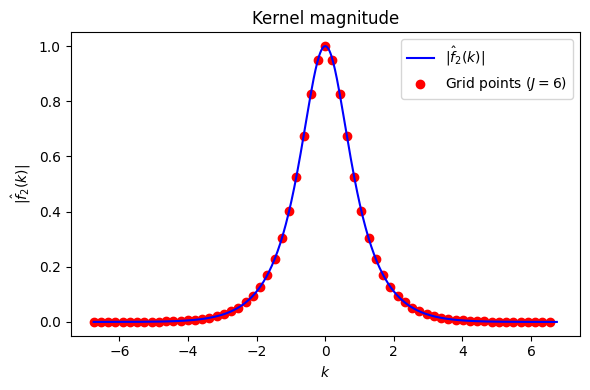

In [11]:
_, j_vals, k_vals = lchs_grid(R, J_SIZE)
fhat_vals = kernel_func(k_vals) ** 2

k_fine = np.linspace(-R, R, 500)
fhat_fine = kernel_func(k_fine) ** 2

plt.figure(figsize=(6, 4))
plt.plot(k_fine, np.abs(fhat_fine), "b-", linewidth=1.5, label=r"$|\hat{f}_2(k)|$")
plt.scatter(k_vals, np.abs(fhat_vals), c="r", label=f"Grid points ($J={J_SIZE}$)")
plt.xlabel("$k$")
plt.ylabel(r"$|\hat{f}_2(k)|$")
plt.title("Kernel magnitude")
plt.legend()
plt.tight_layout()
plt.show()

The full LCHS circuit wraps these steps in a `within_apply` pattern:

In [12]:
@qfunc
def lchs(qvar: LchsVar, aux: QBit, t: float):
    """Full LCHS routine: kernel preparation + Hamiltonian simulation + phase."""
    within_apply(
        lambda: prepare_lchs_kernel(qvar.j),
        lambda: [
            lchs_hamiltonian_simulation(qvar, aux, t),
            apply_kernel_phase(qvar.j),
        ],
    )

### Running the Quantum Circuit

We define the main function, synthesize the circuit, and execute it using a statevector simulator. We post-select on the block register being $|0\rangle$ to extract the LCHS output state.

In [13]:
np.random.seed(1)
v0 = np.random.rand(2**STATE_SIZE)
v0 /= np.linalg.norm(v0)


@qfunc
def initial_state_prep(x: QNum):
    inplace_prepare_amplitudes(v0, 0, x)


@qfunc
def main(x: Output[QNum[STATE_SIZE]], block: Output[QNum]):
    lchs_qvar = LchsVar()
    allocate(lchs_qvar)
    gqsp_aux = QBit()
    allocate(gqsp_aux)

    initial_state_prep(lchs_qvar.x)
    lchs(lchs_qvar, gqsp_aux, T)

    bind([lchs_qvar, gqsp_aux], [x, block])

In [14]:
qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3CJZsTcki5NvhuXNzOIK9EgTVle


In [16]:
sv = calculate_state_vector(qprog)
post_selected = sv[sv.block == 0].sort_values("x")
q_out = post_selected.amplitude.values

display(post_selected)

Submitting job to simulator
Job: https://platform.classiq.io/jobs/53c14875-06f8-4f2f-8811-8f544efd99f5


,x,block,amplitude,magnitude,phase,probability,bitstring
58,0,0,-0.009290+0.039227j,0.04,0.57π,0.001625,00000000000000
8,1,0,-0.162077-0.048177j,0.17,-0.91π,0.028590,00000000000001
40,2,0,-0.016073+0.054032j,0.06,0.59π,0.003178,00000000000010
29,3,0,-0.032474+0.071042j,0.08,0.64π,0.006101,00000000000011


## Quantum vs. Classical Comparison

We compare the quantum LCHS output against:

1. **Exact**: Direct matrix exponentiation $e^{-(L+iH)t}|u_0\rangle$.
2. **LCHS (classical)**: Classical emulation of the quantum circuit (discretized LCHS with the GQSP polynomial approximation).

For this demonstration, we use the block-encodings defined above.

In [17]:
H_mat = pauli_operator_to_matrix(H_PAULI)
L_mat = pauli_operator_to_matrix(L_PAULI)
exact_out = truth_nonunitary(v0, L_mat, H_mat, T)

lchs_out, *_ = lchs_classical(
    v0,
    L_mat,
    H_mat,
    T,
    R=R,
    J=J_SIZE,
    gamma=gamma,
    c=c,
)

normalization = np.sqrt(post_selected.probability.sum())

print(f"Fidelity (quantum vs LCHS classical): {fidelity(q_out, lchs_out):.6f}")
print(f"Fidelity (quantum vs exact):          {fidelity(q_out, exact_out):.6f}")
print(f"Sub-normalization Factor (amplitude):   {normalization:.6f}")

assert np.isclose(fidelity(q_out, exact_out), 1, atol=EPS)

Fidelity (quantum vs LCHS classical): 1.000000
Fidelity (quantum vs exact):          1.000000
Sub-normalization Factor (amplitude):   0.198731


## Technical Notes

1. **Access model**: The algorithm assumes block-encoding access to $H$ and $L$ separately. If only access to $A = L + iH$ is available, one can extract $H$ and $L$ via $H = \frac{1}{2i}(A - A^\dagger)$ and $L = \frac{1}{2}(A + A^\dagger)$, though this may double the block-encoding cost. Alternatively, as noted in [\[5\]](#ref-optimal-lchs) (Sec. 1.1.5), one can block-encode $kL + H$ directly from a block-encoding of $A$ using the identity $kL + H = \frac{(k-i)A + ((k-i)A)^\dagger}{2}$.

2. **Time-dependent case**: If $H$ or $L$ are time-dependent, the inner Hamiltonian simulation becomes time-dependent and can be handled using methods such as Dyson or Magnus series (see the [Time Marching](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_differential_equations_solvers/time_marching/time_marching.ipynb) notebook). The LCHS framework in [\[5\]](#ref-optimal-lchs) is stated in full generality for time-dependent $A(t)$.

3. **Normalization and post-selection**: The LCU of the kernel introduces a normalization factor $\alpha_{\hat{f}_2} = e^c \operatorname{erfc}(1/(2\gamma)) \leq e^c$, which is $\Theta(1)$ for constant $c$ [\[5\]](#ref-optimal-lchs). The final result is obtained by post-selecting on all block qubits being $|0\rangle$, with success probability determined by this normalization and the GQSP scaling factor.

4. **Scalable kernel preparation**: The `inplace_prepare_amplitudes` function used here loads arbitrary amplitudes but does not scale efficiently. [\[5\]](#ref-optimal-lchs) (Theorem 4) provides an efficient circuit for preparing the kernel state with $\mathcal{O}(\log(\|L\| + \log(1/\epsilon)) \log^{5/2}(1/\epsilon))$ two-qubit gates.

## References

<a id='ref-lchs'>[1]</a> An, D., Liu, J.-P., & Lin, L. *Linear Combination of Hamiltonian Simulation for Nonunitary Dynamics with Optimal State Preparation Cost.* Physical Review Letters **131**, 150603 (2023). [arXiv:2303.01029](https://arxiv.org/abs/2303.01029)

<a id='ref-lchs2'>[2]</a> An, D., Childs, A. M., & Lin, L. *Quantum algorithm for linear non-unitary dynamics with near-optimal dependence on all parameters.* Communications in Mathematical Physics (2025). [arXiv:2312.03916](https://arxiv.org/abs/2312.03916)

<a id='ref-gqsp'>[3]</a> Motlagh, D. & Wiebe, N. *Generalized Quantum Signal Processing.* PRX Quantum **5**, 020368 (2024). [arXiv:2308.01501](https://arxiv.org/abs/2308.01501)

<a id='ref-hamiltonian-sim'>[4]</a> [Hamiltonian Simulation with Block Encoding (Classiq Library)](https://github.com/Classiq/classiq-library/blob/main/algorithms/hamiltonian_simulation/hamiltonian_simulation_with_block_encoding/hamiltonian_simulation_with_block_encoding.ipynb)

<a id='ref-optimal-lchs'>[5]</a> Low, G. H. & Somma, R. D. *Optimal quantum simulation of linear non-unitary dynamics.* (2025). [arXiv:2508.19238](https://arxiv.org/abs/2508.19238)